In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import joblib


In [186]:
df = pd.read_csv('train.csv')

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Dataset Overview

In [187]:
df.shape

(2000, 21)

In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [189]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [190]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

EDA

Target Distribution

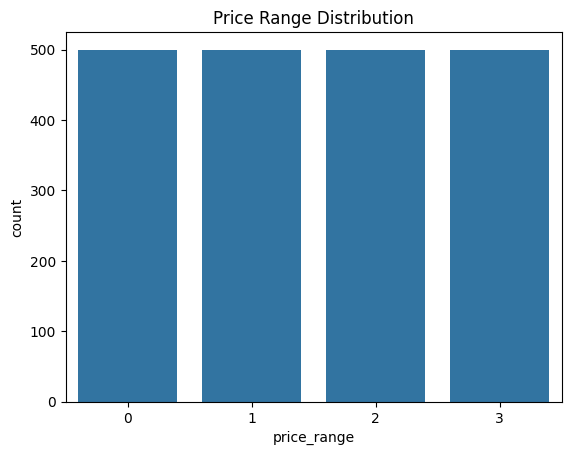

In [192]:
sns.countplot(x='price_range', data=df)
plt.title('Price Range Distribution')
plt.show()

Correlation

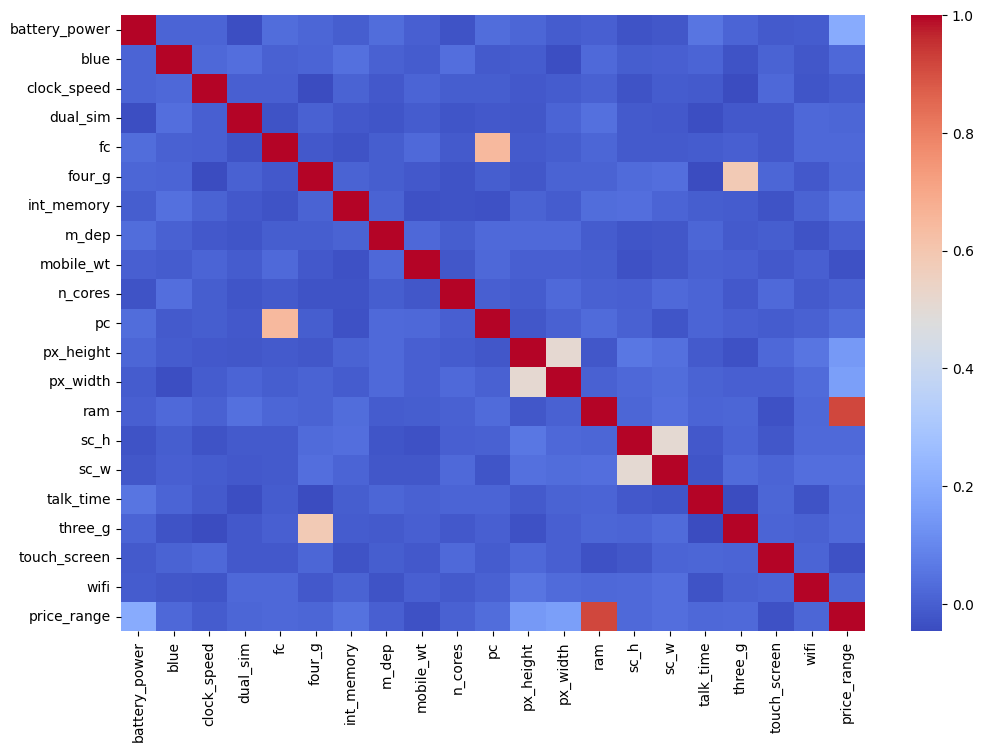

In [193]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

Define the target

In [194]:
X = df.drop("price_range", axis=1)
y = df['price_range']

In [195]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

build a pipeline

In [197]:
lr_pipeline = Pipeline([
    ("scaller", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)

print("Logistic Regression")
print("------------------------")
print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))
print("classification_ report:", classification_report(y_test, lr_pred))

Logistic Regression
------------------------
Logistic Accuracy: 0.975
classification_ report:               precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.98      0.96      0.97       100
           2       0.98      0.96      0.97       100
           3       0.97      0.99      0.98       100

    accuracy                           0.97       400
   macro avg       0.98      0.98      0.97       400
weighted avg       0.98      0.97      0.97       400



Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("------------------")
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Classification Report:", classification_report(y_test, rf_pred))

Random Forest
------------------
RF Accuracy: 0.89
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.97      0.93       100
           1       0.88      0.78      0.83       100
           2       0.84      0.86      0.85       100
           3       0.94      0.95      0.95       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



XGBoost

In [206]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost")
print("----------------")
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost Classification Report:", classification_report(y_test, xgb_pred))

XGBoost
----------------
XGBoost Accuracy: 0.9125
XGBoost Classification Report:               precision    recall  f1-score   support

           0       0.92      0.94      0.93       100
           1       0.89      0.88      0.88       100
           2       0.90      0.89      0.89       100
           3       0.94      0.94      0.94       100

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



lightGBM

In [207]:
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

print("lightGBM")
print("------------")
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))
print("LightGBM Classification Report:", classification_report(y_test, lgb_pred))

lightGBM
------------
LightGBM Accuracy: 0.9125
LightGBM Classification Report:               precision    recall  f1-score   support

           0       0.95      0.93      0.94       100
           1       0.90      0.92      0.91       100
           2       0.89      0.88      0.88       100
           3       0.91      0.92      0.92       100

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



In [220]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lrl_pred = lr.predict(X_test)

print("Logistic Regression")
print("-----------------------")
print("LR:", accuracy_score(y_test, lrl_pred))
print("LR Classification Report:", classification_report(y_test, lrl_pred))

Logistic Regression
-----------------------
LR: 0.62
LR Classification Report:               precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.55      0.57      0.56       100
           2       0.47      0.44      0.45       100
           3       0.63      0.69      0.66       100

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross Validation

In [208]:
scores = cross_val_score(lgb, X, y, cv=5)

print(scores)
print(scores.mean())

[0.9125 0.9325 0.93   0.905  0.8975]
0.9155


In [212]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgb,
}

In [216]:
def evaluate_models(models, X, y, cv=5):
    
    results = []

    for name, model in models.items():
        
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )
        
        results.append({
            "Model": name,
            "Mean Accuracy": scores.mean(),
            "Std": scores.std()
        })

        print(f"{name}")
        print("Scores:", scores)
        print("Mean:", scores.mean())
        print("-"*30)

    results_df = pd.DataFrame(results)

    return results_df

In [217]:
cv_results = evaluate_models(models, X, y)

cv_results

Logistic Regression
Scores: [0.96   0.9575 0.9675 0.965  0.9675]
Mean: 0.9635
------------------------------
Random Forest
Scores: [0.8775 0.8775 0.9    0.88   0.8675]
Mean: 0.8805
------------------------------
XGBoost
Scores: [0.91   0.92   0.91   0.9075 0.89  ]
Mean: 0.9075
------------------------------
LightGBM
Scores: [0.9125 0.9325 0.93   0.905  0.8975]
Mean: 0.9155
------------------------------


,Model,Mean Accuracy,Std
0,Logistic Regression,0.9635,0.004062
1,Random Forest,0.8805,0.010654
2,XGBoost,0.9075,0.009747
3,LightGBM,0.9155,0.013730


In [223]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance
13,ram,6789
0,battery_power,4812
12,px_width,3279
11,px_height,2961
8,mobile_wt,1253
6,int_memory,800
16,talk_time,722
14,sc_h,639
10,pc,617
7,m_dep,576


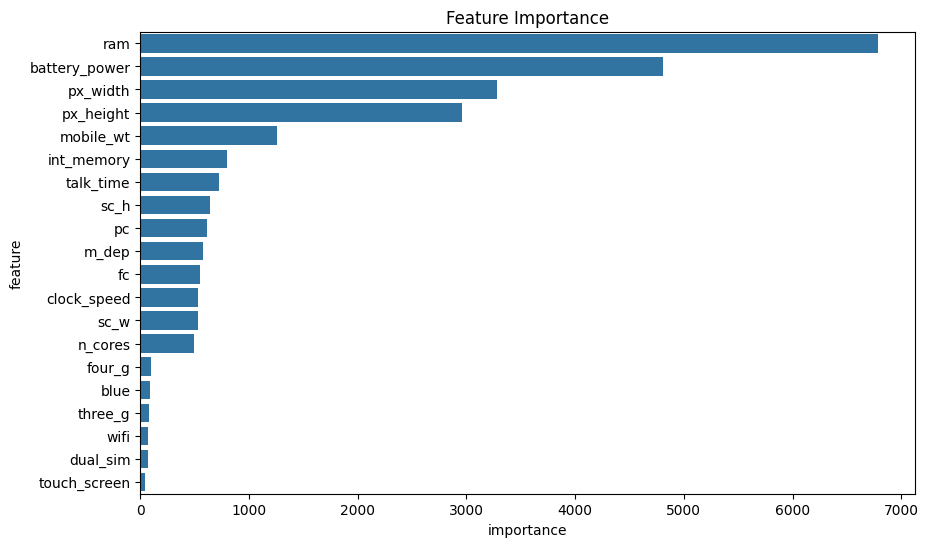

In [224]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=importance
)
plt.title("Feature Importance")
plt.show()

TensorFlow Neural Network

Model

In [225]:
from tensorflow.keras import layers
model = Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(4, activation="softmax")

])

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile

In [ ]:
print(tf.config)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [228]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2945 - loss: 85.9480 - val_accuracy: 0.4125 - val_loss: 8.6161
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3578 - loss: 26.3742 - val_accuracy: 0.4187 - val_loss: 2.2312
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3320 - loss: 14.8336 - val_accuracy: 0.2562 - val_loss: 1.3730
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3039 - loss: 9.0227 - val_accuracy: 0.2375 - val_loss: 1.3868
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3008 - loss: 6.9905 - val_accuracy: 0.2344 - val_loss: 1.3878
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3328 - loss: 4.6955 - val_accuracy: 0.2344 - val_loss: 1.3884
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2977 - loss: 3.7006 - val_accuracy: 0.2344 - val_loss: 1.3891
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3047 - loss: 3.1545 - val_accuracy: 0.2344 - val_l

Evaluate NN

In [229]:
loss, acc = model.evaluate(X_test, y_test)

print(acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4475 - loss: 1.1442  
0.44749999046325684


confusion Matrix

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


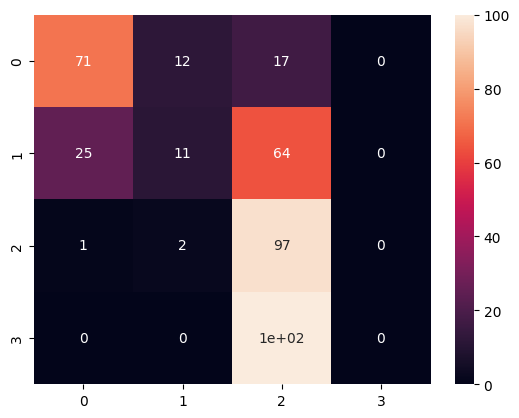

In [230]:
pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True)
plt.show()

Model Comparison

In [231]:
print("Logistic:", accuracy_score(y_test, lr_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("XGB:", accuracy_score(y_test, xgb_pred))
print("LGB:", accuracy_score(y_test, lgb_pred))
print("NN:", acc)

Logistic: 0.975
RF: 0.89
XGB: 0.9125
LGB: 0.9125
NN: 0.44749999046325684


Save Best Model

In [232]:
joblib.dump(lgb, "mobile_price_lgbm.pkl")

['mobile_price_lgbm.pkl']